# 03 — Visualizations

Produces eight figures saved to `../output/`:

- **Fig 1** `fig1_sdpi_map.png` — U.S. choropleth of hybrid SDPI
- **Fig 2** `fig2_regional_violin.png` — Regional distribution violin plots
- **Fig 3** `fig3_domain_heatmap.png` — State × policy-domain heatmap
- **Fig 8** `fig8_ranked_bar_regional.png` — Region-colored ranking bar chart (for presentation)

Figures 4–7 (PCA scree, biplot, PC1 vs SDPI, domain correlations) are produced in `04_pca_analysis.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load processed data

In [2]:
df = pd.read_csv("../data/sdpi_processed.csv")
df.shape

(51, 47)

## Figure 1 — U.S. Choropleth Map (Hybrid SDPI)

Requires `geopandas` and the GeoJSON file in `../data/us_states.geojson`.

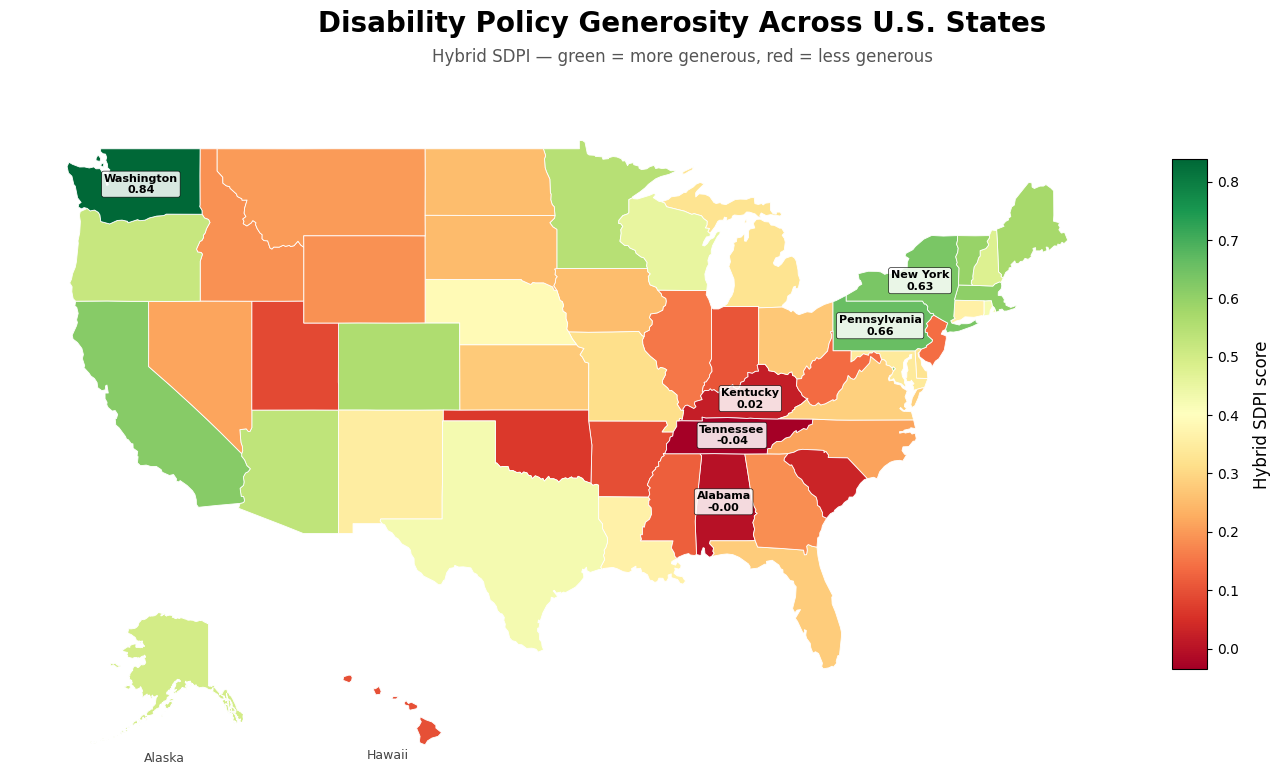

Saved fig1_sdpi_map.png


In [3]:
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

gdf = gpd.read_file("../data/us_states.geojson")
merged = gdf.merge(df, left_on="name", right_on="State", how="left")
continental = merged[~merged["name"].isin(["Alaska","Hawaii","Puerto Rico"])].copy()
alaska = merged[merged["name"]=="Alaska"].copy()
hawaii = merged[merged["name"]=="Hawaii"].copy()
vmin, vmax = df["sdpi_hybrid"].min(), df["sdpi_hybrid"].max()
norm = Normalize(vmin=vmin, vmax=vmax); cmap = "RdYlGn"
fig = plt.figure(figsize=(14,8.5))
ax_main = fig.add_axes([0.02,0.08,0.78,0.85])
ax_ak   = fig.add_axes([0.04,0.10,0.18,0.18])
ax_hi   = fig.add_axes([0.24,0.10,0.10,0.10])
cax     = fig.add_axes([0.85,0.20,0.025,0.6])
continental.plot(ax=ax_main,column="sdpi_hybrid",cmap=cmap,norm=norm,edgecolor="white",linewidth=0.6,missing_kwds={"color":"lightgrey"})
ax_main.set_xlim(-128,-65); ax_main.set_ylim(23,51); ax_main.set_axis_off()
alaska.plot(ax=ax_ak,column="sdpi_hybrid",cmap=cmap,norm=norm,edgecolor="white",linewidth=0.6)
ax_ak.set_xlim(-180,-130); ax_ak.set_ylim(50,73); ax_ak.set_axis_off()
ax_ak.text(0.5,-0.05,"Alaska",ha="center",transform=ax_ak.transAxes,fontsize=9,color="#444")
hawaii.plot(ax=ax_hi,column="sdpi_hybrid",cmap=cmap,norm=norm,edgecolor="white",linewidth=0.6)
ax_hi.set_xlim(-161,-154); ax_hi.set_ylim(18.5,22.5); ax_hi.set_axis_off()
ax_hi.text(0.5,-0.05,"Hawaii",ha="center",transform=ax_hi.transAxes,fontsize=9,color="#444")
sm = ScalarMappable(norm=norm,cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm,cax=cax); cbar.set_label("Hybrid SDPI score",fontsize=12,labelpad=10)
fig.text(0.5,0.95,"Disability Policy Generosity Across U.S. States",ha="center",fontsize=20,fontweight="bold")
fig.text(0.5,0.915,"Hybrid SDPI — green = more generous, red = less generous",ha="center",fontsize=12,color="#555")
for _,row in continental.nlargest(3,"sdpi_hybrid").iterrows():
    cx,cy=row.geometry.centroid.x,row.geometry.centroid.y
    ax_main.annotate(f"{row['State']}\n{row['sdpi_hybrid']:.2f}",xy=(cx,cy),ha="center",va="center",fontsize=8,fontweight="bold",bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="black",alpha=0.85,lw=0.5))
for _,row in continental.nsmallest(3,"sdpi_hybrid").iterrows():
    cx,cy=row.geometry.centroid.x,row.geometry.centroid.y
    ax_main.annotate(f"{row['State']}\n{row['sdpi_hybrid']:.2f}",xy=(cx,cy),ha="center",va="center",fontsize=8,fontweight="bold",bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="black",alpha=0.85,lw=0.5))
plt.savefig("../output/fig1_sdpi_map.png",dpi=200,bbox_inches="tight",facecolor="white")
plt.show(); print("Saved fig1_sdpi_map.png")

## Figure 2 — Regional violin + strip plot

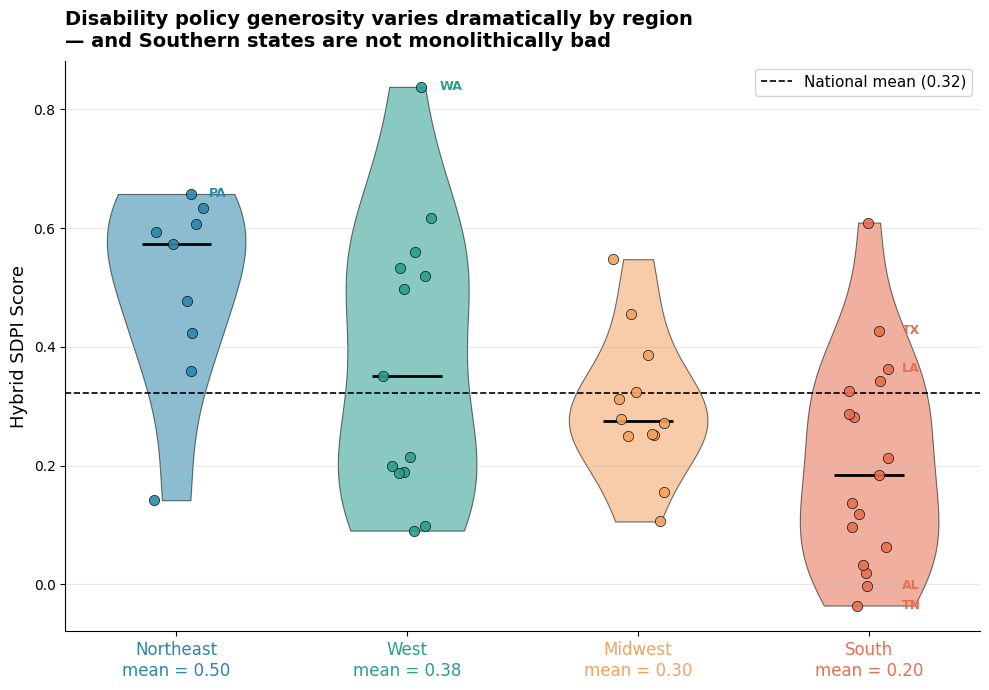

Saved fig2_regional_violin.png


In [4]:
import numpy as np
import matplotlib.patches as mpatches

region_colors = {"Northeast":"#2E86AB","Midwest":"#F4A261","South":"#E76F51","West":"#2A9D8F"}
region_order  = ["Northeast","West","Midwest","South"]

fig, ax = plt.subplots(figsize=(10, 7))
parts = ax.violinplot([df[df["region"]==r]["sdpi_hybrid"].values for r in region_order],
                      positions=range(4), showmedians=True, showextrema=False, widths=0.6)
for pc, r in zip(parts["bodies"], region_order):
    pc.set_facecolor(region_colors[r]); pc.set_alpha(0.55); pc.set_edgecolor("black"); pc.set_linewidth(0.8)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
rng = np.random.default_rng(42)
for i, r in enumerate(region_order):
    sub = df[df["region"]==r]["sdpi_hybrid"].values
    jitter = rng.uniform(-0.12,0.12,len(sub))
    ax.scatter(i+jitter, sub, color=region_colors[r], edgecolor="black", linewidth=0.5, s=55, zorder=3, alpha=0.9)
for lbl_state, abbr in {"Washington":"WA","Pennsylvania":"PA","Tennessee":"TN","Alabama":"AL","Louisiana":"LA","Texas":"TX"}.items():
    row = df[df["State"]==lbl_state].iloc[0]
    i = region_order.index(row["region"])
    ax.annotate(abbr, xy=(i+0.14, row["sdpi_hybrid"]), fontsize=9, fontweight="bold", color=region_colors[row["region"]], va="center")
nat_mean = df["sdpi_hybrid"].mean()
ax.axhline(nat_mean, color="black", linestyle="--", linewidth=1.2, label=f"National mean ({nat_mean:.2f})")
tick_labels = [f"{r}\nmean = {df[df['region']==r]['sdpi_hybrid'].mean():.2f}" for r in region_order]
ax.set_xticks(range(4)); ax.set_xticklabels(tick_labels, fontsize=12)
for tick, r in zip(ax.get_xticklabels(), region_order): tick.set_color(region_colors[r])
ax.set_ylabel("Hybrid SDPI Score", fontsize=13)
ax.set_title("Disability policy generosity varies dramatically by region\n— and Southern states are not monolithically bad",
             fontsize=14, fontweight="bold", loc="left", pad=10)
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
for spine in ["top","right"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("../output/fig2_regional_violin.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved fig2_regional_violin.png")

## Figure 3 — State × Policy-Domain Heatmap

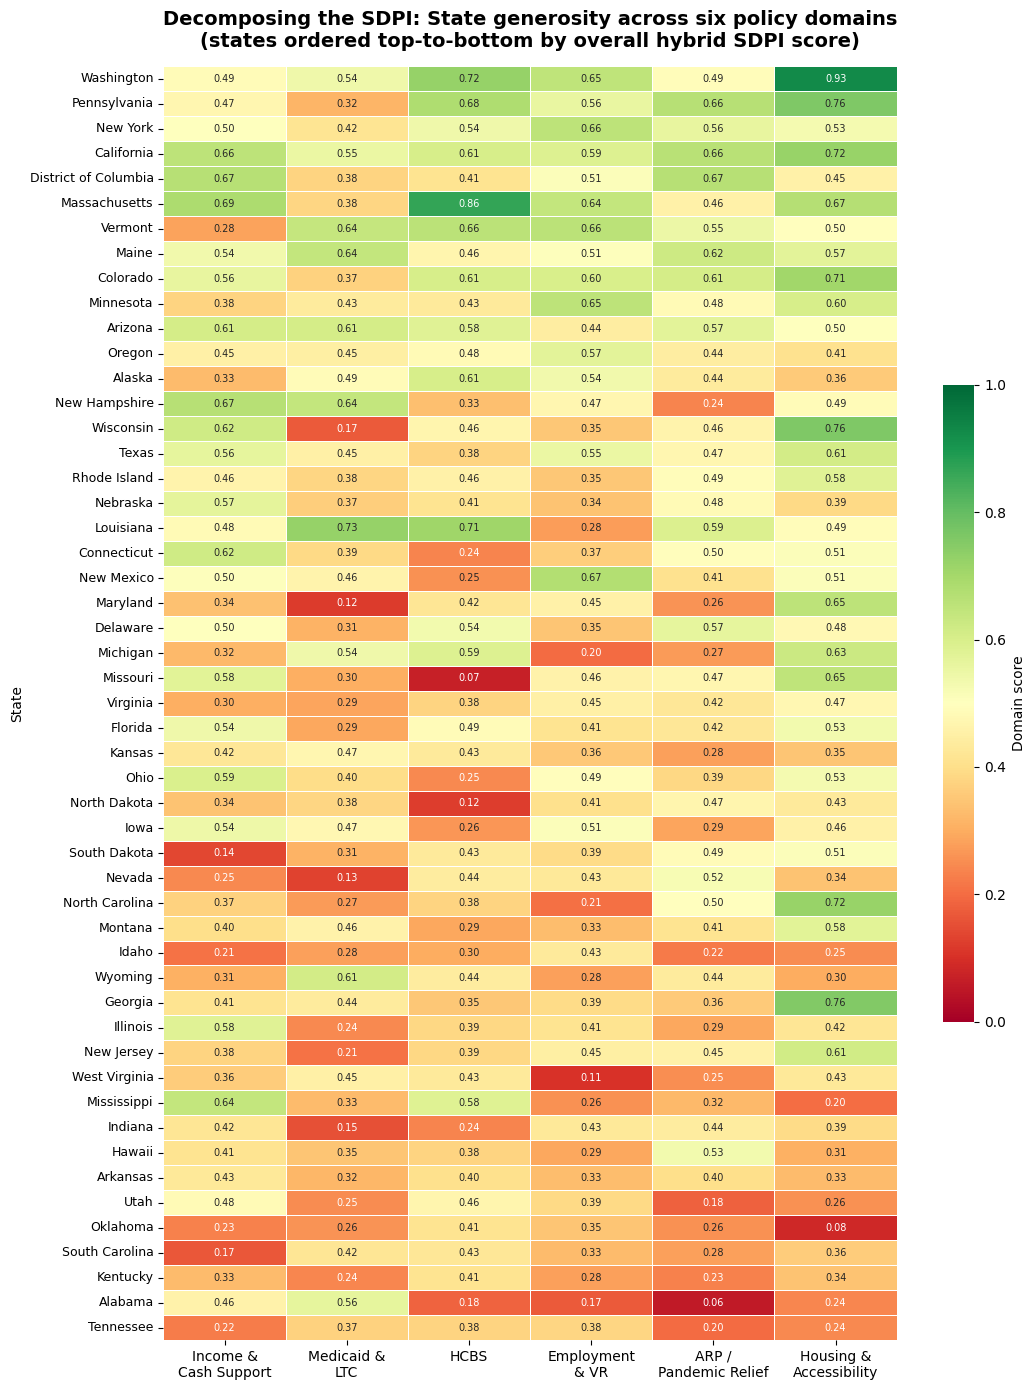

Saved fig3_domain_heatmap.png


In [5]:
domain_labels = {
    "domain_Income & Cash Support":   "Income &\nCash Support",
    "domain_Medicaid & LTC":          "Medicaid &\nLTC",
    "domain_HCBS":                    "HCBS",
    "domain_Employment & VR":         "Employment\n& VR",
    "domain_ARP / Pandemic Relief":   "ARP /\nPandemic Relief",
    "domain_Housing & Accessibility": "Housing &\nAccessibility",
}
dom_cols = [c for c in df.columns if c.startswith("domain_")]
heat = df[["State"] + dom_cols + ["sdpi_hybrid"]].sort_values("sdpi_hybrid",ascending=False)
heat_matrix = heat.set_index("State")[dom_cols]
heat_matrix.columns = [domain_labels.get(c,c) for c in heat_matrix.columns]
fig, ax = plt.subplots(figsize=(11,14))
sns.heatmap(heat_matrix,cmap="RdYlGn",annot=True,fmt=".2f",annot_kws={"fontsize":7},
            linewidths=0.4,linecolor="white",cbar_kws={"label":"Domain score","shrink":0.5},vmin=0,vmax=1,ax=ax)
ax.set_title("Decomposing the SDPI: State generosity across six policy domains\n"
             "(states ordered top-to-bottom by overall hybrid SDPI score)",fontsize=14,fontweight="bold",pad=14)
ax.tick_params(axis="x",labelsize=10,rotation=0); ax.tick_params(axis="y",labelsize=9)
plt.tight_layout()
plt.savefig("../output/fig3_domain_heatmap.png",dpi=200,bbox_inches="tight",facecolor="white")
plt.show(); print("Saved fig3_domain_heatmap.png")

## Figure 8 — Region-colored ranking bar chart

Used as slide-1 anchor for the presentation.

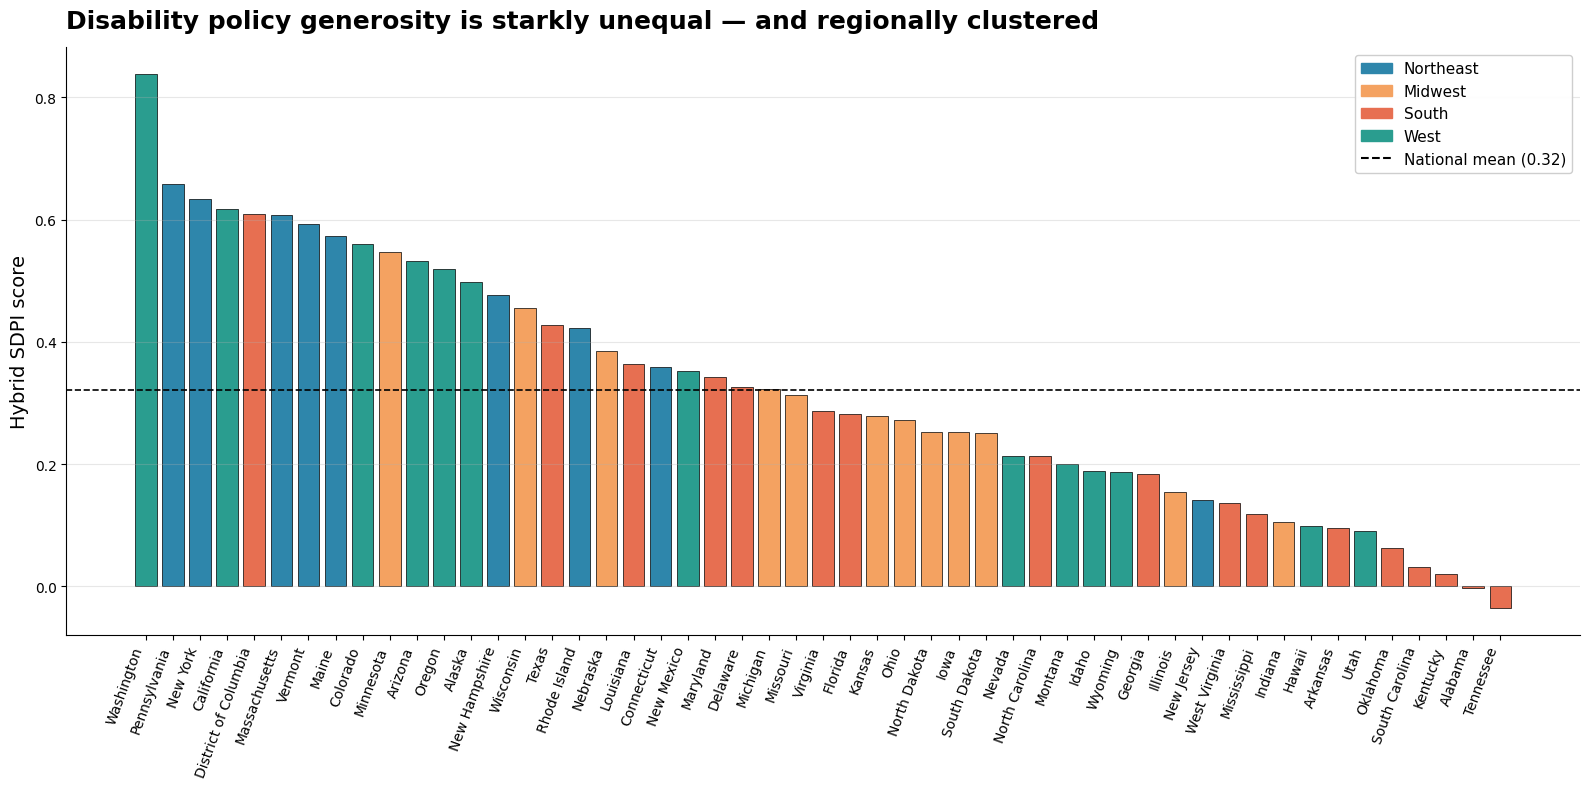

Saved fig8_ranked_bar_regional.png


In [6]:
import matplotlib.patches as mpatches
region_colors = {"Northeast":"#2E86AB","Midwest":"#F4A261","South":"#E76F51","West":"#2A9D8F"}
C = df.sort_values("sdpi_hybrid",ascending=False).reset_index(drop=True)
bar_colors = [region_colors[r] for r in C["region"]]
fig, ax = plt.subplots(figsize=(16,8))
ax.bar(C.index, C["sdpi_hybrid"], color=bar_colors, edgecolor="black", linewidth=0.5)
ax.set_xticks(C.index); ax.set_xticklabels(C["State"],rotation=70,ha="right",fontsize=10)
nat_mean = C["sdpi_hybrid"].mean()
ax.axhline(nat_mean,color="black",linestyle="--",linewidth=1.2,label=f"National mean ({nat_mean:.2f})")
handles = [mpatches.Patch(color=c,label=r) for r,c in region_colors.items()]
handles.append(plt.Line2D([0],[0],color="black",linestyle="--",label=f"National mean ({nat_mean:.2f})"))
ax.legend(handles=handles,fontsize=11,loc="upper right",framealpha=0.95)
ax.set_ylabel("Hybrid SDPI score",fontsize=14); ax.grid(axis="y",alpha=0.3)
ax.set_title("Disability policy generosity is starkly unequal — and regionally clustered",fontsize=18,fontweight="bold",pad=14,loc="left")
for spine in ["top","right"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("../output/fig8_ranked_bar_regional.png",dpi=200,bbox_inches="tight",facecolor="white")
plt.show(); print("Saved fig8_ranked_bar_regional.png")